## <center><b> IMPORTING NECESSARY PACKAGES</b></center>

In [1]:

import sys
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')



import math
import scipy
import sklearn
from nltk.corpus import stopwords
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer



from surprise import SVD, NMF
from surprise import Dataset, Reader
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV



import re
import os, sys
import ipywidgets as widgets
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from contextlib import contextmanager
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import correlation
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import pairwise_distances


## <center><b> IMPORTING THE DATASET </b></center>

In [2]:
def load_data(filename):
    
    df = pd.read_csv(f'{filename}.csv',sep=';',error_bad_lines=False,warn_bad_lines=False,encoding='latin-1')
    
    return df

In [3]:
books_df   = load_data("BX-CSV-Dump/BX-Books")
users_df   = load_data("BX-CSV-Dump/BX-Users")
ratings_df = load_data("BX-CSV-Dump/BX-Book-Ratings")

In [4]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
users_df.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
ratings_df.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


<b><font color='black'>Dimension of dataset

In [7]:
# dimension of dataset
print(f'''Dimension of Books dataset  is {books_df.shape} 
Dimension of Ratings dataset is {ratings_df.shape} 
Dimension of Users_df dataset is {users_df.shape}''')

Dimension of Books dataset  is (271360, 8) 
Dimension of Ratings dataset is (1149780, 3) 
Dimension of Users_df dataset is (278858, 3)


## User's Dataset

In [8]:
def missing_values(df):
    Values_Missing=df.isnull().sum()
    Values_Missing_percent=round(df.isnull().mean().mul(100),2)
    temp_table=pd.concat([Values_Missing,Values_Missing_percent],axis=1)
    temp_table=temp_table.rename(
    columns={df.index.name:'col_name',0:'Missing Values',1:'% of Total Values'})
    temp_table['Data_type']=df.dtypes
    temp_table=temp_table.sort_values('% of Total Values',ascending=False)
    return temp_table.reset_index()

In [9]:
missing_values(users_df)

,index,Missing Values,% of Total Values,Data_type
0,Age,110762,39.72,float64
1,User-ID,0,0.00,int64
2,Location,0,0.00,object


#### Age Distribution

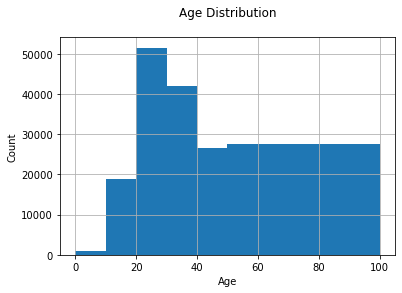

In [10]:
users_df.Age.hist(bins=[0, 10, 20, 30, 40, 50, 100])
plt.title('Age Distribution\n')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Find outlier data in Age column')

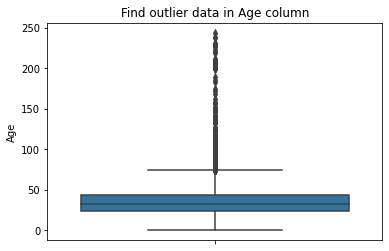

In [11]:
sns.boxplot(y='Age', data=users_df)
plt.title('Find outlier data in Age column')

In [12]:
print(sorted(users_df.Age.unique()))

[nan, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 113.0, 114.0, 115.0, 116.0, 118.0, 119.0, 123.0, 124.0, 127.0, 128.0, 132.0, 133.0, 136.0, 137.0, 138.0, 140.0, 141.0, 143.0, 146.0, 147.0, 148.0, 151.0, 152.0, 156.0, 157.0, 159.0, 162.0, 168.0, 172.0, 175.0, 183.0, 186.0, 189.0, 199.0, 200.0, 201.0, 204.0, 207.0, 208.0, 209.0, 210.0, 212.0, 219.0, 220.0, 223.0, 226.0

#### There are outlier present in the dataset for the column age.

### Replacing location with county to reduce the number to unique item is the column

In [13]:
users_df.Location.nunique()

57339

In [14]:
for i in users_df:
    users_df['Country']=users_df.Location.str.extract(r'\,+\s?(\w*\s?\w*)\"*$')   

In [15]:
users_df.Country.nunique()

529

In [16]:
#drop location column
users_df.drop('Location',axis=1,inplace=True)

In [17]:
## Top 5 record after dropping

users_df.head(5)

,User-ID,Age,Country
0,1,NaN,usa
1,2,18.0,usa
2,3,NaN,russia
3,4,17.0,portugal
4,5,NaN,united kingdom


## Checking for NULLS

In [18]:
users_df.isnull().sum()

User-ID         0
Age        110762
Country       368
dtype: int64

In [19]:
users_df['Country']=users_df['Country'].astype('str')  ## converting data type

## Obtaining unique value
value =list(users_df.Country.unique())
value = [x for x in value if x is not None]
value.sort()
print(value)

['', '01776', '02458', '19104', '23232', '30064', '85021', '87510', '_ brasil', 'a', 'aaa', 'adsgfdr', 'afghanistan', 'ahrensburg', 'alachua', 'albania', 'alderney', 'algeria', 'algérie', 'allen', 'ama lurra', 'america', 'american samoa', 'andorra', 'angola', 'antarctica', 'aotearoa', 'argentina', 'armenia', 'aroostook', 'aruba', 'asturies', 'auckland', 'austbritania', 'australia', 'australii', 'austria', 'autralia', 'az', 'azerbaijan', 'bademn würtemberg', 'bahamas', 'bahrain', 'baltimore', 'bangladesh', 'barbados', 'basilicata', 'basque country', 'bavaria', 'baxter', 'bbbzzzzz', 'belarus', 'belgi', 'belgique', 'belgium', 'belize', 'bell', 'benin', 'berguedà', 'bermuda', 'bernalillo', 'bfe', 'bhutan', 'bih', 'bkk', 'bladen', 'bolivia', 'bosnia', 'botswana', 'brasil', 'brazil', 'brunei', 'brunei darussalam', 'bucks', 'bulgaria', 'buncombe', 'burkina faso', 'burkinafasu', 'burlington', 'burma', 'butler', 'c', 'cadd0', 'calabria', 'california', 'cambodia', 'camden', 'cameroon', 'can', 'c

### Correcting the spelling

In [20]:
users_df['Country'].replace(['','01776','02458','19104','23232','30064','85021','87510','alachua','america','austria','autralia','cananda','geermany','italia','united kindgonm','united sates','united staes','united state','united states','us'],
                           ['other','usa','usa','usa','usa','usa','usa','usa','usa','usa','australia','australia','canada','germany','italy','united kingdom','usa','usa','usa','usa','usa'],inplace=True)

Text(0.5, 1.0, 'Number of User in Each Country')

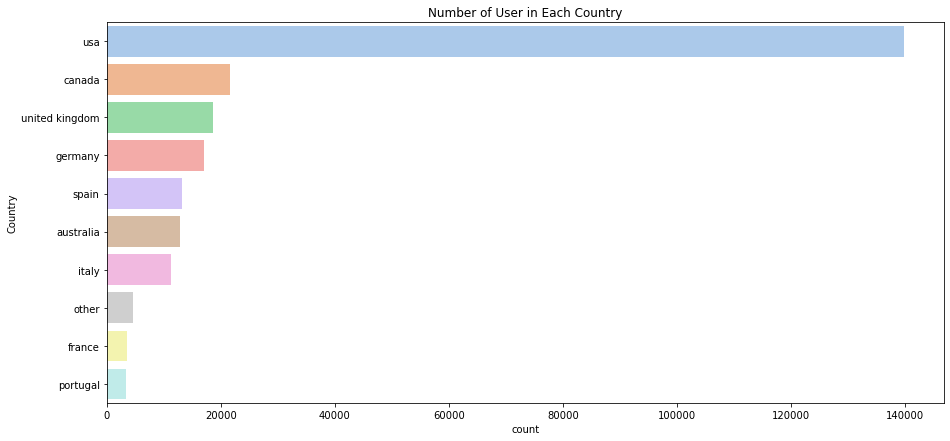

In [21]:
plt.figure(figsize=(15,7))
sns.countplot(y='Country',data=users_df,order=pd.value_counts(users_df['Country']).iloc[:10].index,palette='pastel' )
plt.title('Number of User in Each Country')

### Dealing with outliers in User's Age

Text(0.5, 1.0, 'Age Distribution Plot')

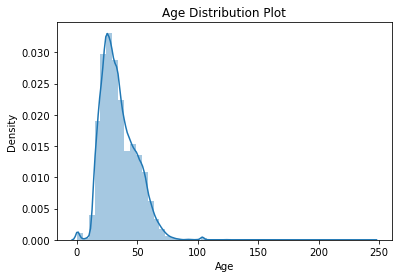

In [22]:
sns.distplot(users_df.Age)
plt.title('Age Distribution Plot')

### Setting nan for ages above 100 and below 5

In [23]:
# outlier data became NaN
users_df.loc[(users_df.Age > 100) | (users_df.Age < 5), 'Age'] = np.nan

In [24]:
users_df.isna().sum()

User-ID         0
Age        112010
Country         0
dtype: int64

### Filling the user's age by grouping on country and filling it with median

In [25]:
users_df['Age'] = users_df['Age'].fillna(users_df.groupby('Country')['Age'].transform('median'))

In [26]:
users_df.isna().sum()

User-ID      0
Age        276
Country      0
dtype: int64

## Remaining Nan are filled with mean

In [27]:
users_df['Age'].fillna(users_df.Age.mean(),inplace=True)

In [28]:
users_df.isna().sum()

User-ID    0
Age        0
Country    0
dtype: int64

## Book's Dataset

Text(0.5, 1.0, 'Top 10 Authors')

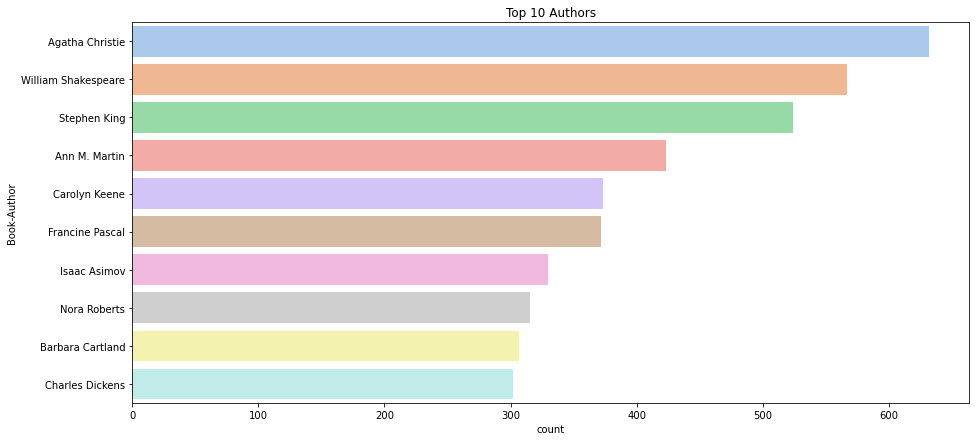

In [29]:
plt.figure(figsize=(15,7))
sns.countplot(y='Book-Author',data=books_df,order=pd.value_counts(books_df['Book-Author']).iloc[:10].index, palette ='pastel')
plt.title('Top 10 Authors')

Text(0.5, 1.0, 'Top 10 Publishers')

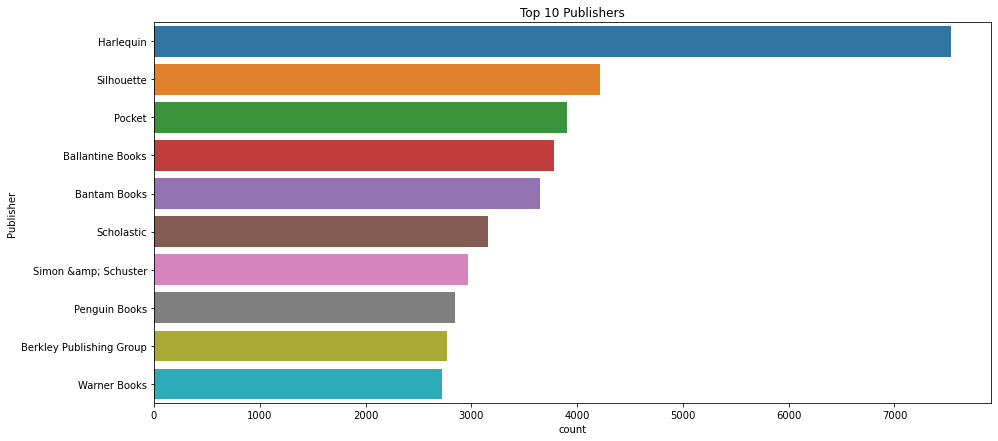

In [30]:
plt.figure(figsize=(15,7))
sns.countplot(y='Publisher',data=books_df,order=pd.value_counts(books_df['Publisher']).iloc[:10].index)
plt.title('Top 10 Publishers')

In [31]:
books_df['Year-Of-Publication']=books_df['Year-Of-Publication'].astype('str')

value =list(books_df['Year-Of-Publication'].unique())
value = [x for x in value if x is not None]
value.sort()
print(value)

['0', '1376', '1378', '1806', '1897', '1900', '1901', '1902', '1904', '1906', '1908', '1909', '1910', '1911', '1914', '1917', '1919', '1920', '1921', '1922', '1923', '1924', '1925', '1926', '1927', '1928', '1929', '1930', '1931', '1932', '1933', '1934', '1935', '1936', '1937', '1938', '1939', '1940', '1941', '1942', '1943', '1944', '1945', '1946', '1947', '1948', '1949', '1950', '1951', '1952', '1953', '1954', '1955', '1956', '1957', '1958', '1959', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2008', '2010', '2011', '2012', '2020', '2021', '2024', '2026', '2030', '2037', '2038', '2050', 'DK Publishing Inc', 'Gallimard']


In [32]:
#investigating the rows having 'DK Publishing Inc' as yearOfPublication
books_df.loc[books_df['Year-Of-Publication'] == 'DK Publishing Inc',:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


In [33]:
#From above, it is seen that bookAuthor is incorrectly loaded with bookTitle, hence making required corrections
#ISBN '0789466953'
books_df.loc[books_df.ISBN == '0789466953','Year-Of-Publication'] = 2000
books_df.loc[books_df.ISBN == '0789466953','Book-Author'] = "James Buckley"
books_df.loc[books_df.ISBN == '0789466953','Publisher'] = "DK Publishing Inc"
books_df.loc[books_df.ISBN == '0789466953','Book-Title'] = "DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)"

#ISBN '078946697X'
books_df.loc[books_df.ISBN == '078946697X','Year-Of-Publication'] = 2000
books_df.loc[books_df.ISBN == '078946697X','Book-Author'] = "Michael Teitelbaum"
books_df.loc[books_df.ISBN == '078946697X','Publisher'] = "DK Publishing Inc"
books_df.loc[books_df.ISBN == '078946697X','Book-Title'] = "DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)"

#rechecking
books_df.loc[(books_df.ISBN == '0789466953') | (books_df.ISBN == '078946697X'),:]
#corrections done

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",Michael Teitelbaum,2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",James Buckley,2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


In [34]:
#investigating the rows having 'Gallimard' as yearOfPublication
books_df.loc[books_df['Year-Of-Publication'] == 'Gallimard',:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN


In [35]:
#making required corrections as above, keeping other fields intact
books_df.loc[books_df.ISBN == '2070426769','Year-Of-Publication'] = 2003
books_df.loc[books_df.ISBN == '2070426769','Book-Author'] = "Jean-Marie Gustave Le ClÃ?Â©zio"
books_df.loc[books_df.ISBN == '2070426769','Publisher'] = "Gallimard"
books_df.loc[books_df.ISBN == '2070426769','Book-Title'] = "Peuple du ciel, suivi de 'Les Bergers"


books_df.loc[books_df.ISBN == '2070426769',:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers",Jean-Marie Gustave Le ClÃ?Â©zio,2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN


In [36]:
books_df['Year-Of-Publication'] = pd.to_numeric(books_df['Year-Of-Publication'], errors='coerce').astype('Int64')

print(sorted(books_df['Year-Of-Publication'].unique()))

[0, 1376, 1378, 1806, 1897, 1900, 1901, 1902, 1904, 1906, 1908, 1909, 1910, 1911, 1914, 1917, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2008, 2010, 2011, 2012, 2020, 2021, 2024, 2026, 2030, 2037, 2038, 2050]


In [37]:
books_df.loc[(books_df['Year-Of-Publication'] > 2006) | (books_df['Year-Of-Publication'] == 0),'Year-Of-Publication'] = np.NAN

#replacing NaNs with median value of Year-Of-Publication
books_df['Year-Of-Publication'].fillna(round(books_df['Year-Of-Publication'].median()), inplace=True)

In [38]:
print(sorted(books_df['Year-Of-Publication'].unique()))

[1376, 1378, 1806, 1897, 1900, 1901, 1902, 1904, 1906, 1908, 1909, 1910, 1911, 1914, 1917, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006]


In [39]:
#exploring 'publisher' column

books_df.loc[books_df.Publisher.isnull(),:]
#two NaNs

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...


In [40]:
#Filling Nan of Publisher with others
books_df.Publisher.fillna('other',inplace=True)

In [41]:
#exploring 'Book-Author' column
books_df.loc[books_df['Book-Author'].isnull(),:]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...


In [42]:
#Filling Nan of Book-Author with others
books_df['Book-Author'].fillna('other',inplace=True)

In [43]:
books_df.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              0
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

## Ratings_df

In [44]:
ratings_df.head(2)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5


In [45]:
ratings_df_new = ratings_df[ratings_df.ISBN.isin(books_df.ISBN)]
ratings_df.shape,ratings_df_new.shape

((1149780, 3), (1031136, 3))

In [46]:
print("Shape of dataset before dropping",ratings_df_new.shape)
ratings_df_new = ratings_df_new[ratings_df_new['User-ID'].isin(users_df['User-ID'])]
print("shape of dataset after dropping",ratings_df_new.shape)

Shape of dataset before dropping (1031136, 3)
shape of dataset after dropping (1031136, 3)


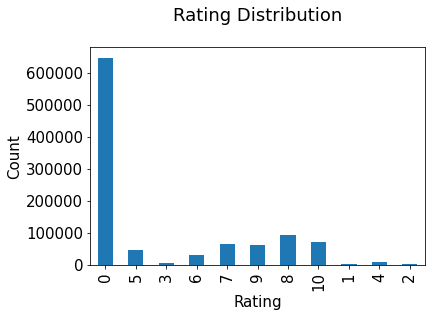

In [47]:
plt.rc("font", size=15)
ratings_df_new['Book-Rating'].value_counts(sort=False).plot(kind='bar')
plt.title('Rating Distribution\n')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [48]:
#Hence segragating implicit and explict ratings datasets

ratings_value_df = ratings_df_new[ratings_df_new['Book-Rating'] != 0]
ratings_null_df = ratings_df_new[ratings_df_new['Book-Rating'] == 0]

In [49]:
print(' dataset shape',ratings_value_df.shape)
print('ratings_implicit dataset',ratings_null_df.shape)

 dataset shape (383842, 3)
ratings_implicit dataset (647294, 3)


<AxesSubplot:xlabel='Book-Rating', ylabel='count'>

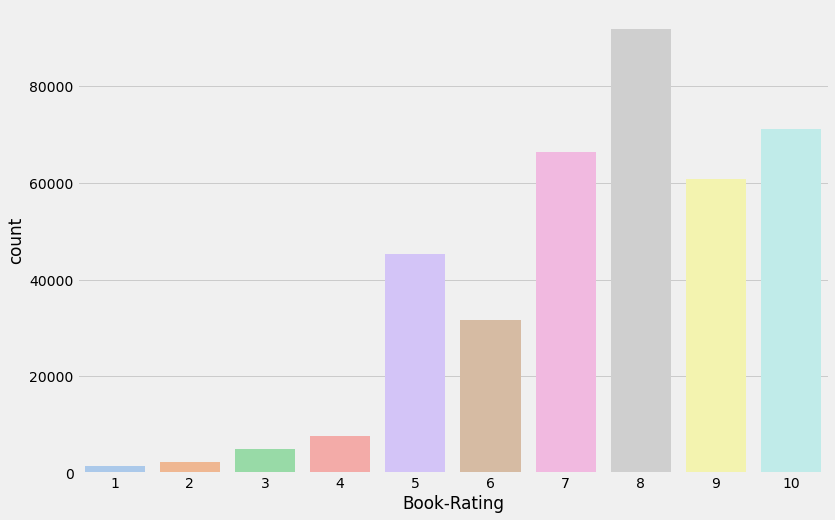

In [50]:
plt.style.use('fivethirtyeight')
plt.figure(figsize=(12, 8))
sns.countplot(data=ratings_value_df , x='Book-Rating', palette='pastel')

In [51]:
rating_total_df = pd.DataFrame(ratings_value_df.groupby('ISBN')['Book-Rating'].count())
rating_total_df.sort_values('Book-Rating', ascending=False).head()

,Book-Rating
ISBN,
0316666343,707
0971880107,581
0385504209,487
0312195516,383
0060928336,320


In [52]:
books_rating_df = pd.DataFrame(['0316666343', '0971880107', '0385504209', '0312195516', '0060928336'], index=np.arange(5), columns = ['ISBN'])
books_rating_df = pd.merge(books_rating_df, books_df, on='ISBN')
books_rating_df

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0316666343,The Lovely Bones: A Novel,Alice Sebold,2002,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...,http://images.amazon.com/images/P/0316666343.0...
1,0971880107,Wild Animus,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
2,0385504209,The Da Vinci Code,Dan Brown,2003,Doubleday,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...,http://images.amazon.com/images/P/0385504209.0...
3,0312195516,The Red Tent (Bestselling Backlist),Anita Diamant,1998,Picador USA,http://images.amazon.com/images/P/0312195516.0...,http://images.amazon.com/images/P/0312195516.0...,http://images.amazon.com/images/P/0312195516.0...
4,0060928336,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Rebecca Wells,1997,Perennial,http://images.amazon.com/images/P/0060928336.0...,http://images.amazon.com/images/P/0060928336.0...,http://images.amazon.com/images/P/0060928336.0...


In [53]:
# Create column Rating average 
ratings_value_df['Avg_Rating']=ratings_value_df.groupby('ISBN')['Book-Rating'].transform('mean')
# Create column Rating sum
ratings_value_df['Total_No_Of_Users_Rated']=ratings_value_df.groupby('ISBN')['Book-Rating'].transform('count')

## Merging All Dataset

In [54]:
booksrecom_final_df=users_df.copy()
booksrecom_final_df=pd.merge(booksrecom_final_df,ratings_value_df,on='User-ID')
booksrecom_final_df=pd.merge(booksrecom_final_df,books_df,on='ISBN')

In [55]:
booksrecom_final_df.head(5)

,User-ID,Age,Country,ISBN,Book-Rating,Avg_Rating,Total_No_Of_Users_Rated,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,8,33.0,canada,0002005018,5,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
1,11676,28.0,nan,0002005018,8,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,67544,30.0,canada,0002005018,8,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
3,116866,32.0,other,0002005018,9,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
4,123629,33.0,canada,0002005018,9,7.666667,9,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...


In [56]:
missing_values(booksrecom_final_df)

,index,Missing Values,% of Total Values,Data_type
0,User-ID,0,0.0,int64
1,Age,0,0.0,float64
2,Country,0,0.0,object
3,ISBN,0,0.0,object
4,Book-Rating,0,0.0,int64
5,Avg_Rating,0,0.0,float64
6,Total_No_Of_Users_Rated,0,0.0,int64
7,Book-Title,0,0.0,object
8,Book-Author,0,0.0,object
9,Year-Of-Publication,0,0.0,Int64


In [57]:
booksrecom_final_df.shape

(383842, 14)

## Popularity Based Recommendation System 

In [58]:
mean_vote= booksrecom_final_df['Avg_Rating'].mean()
min_vote= booksrecom_final_df['Total_No_Of_Users_Rated'].quantile(0.90)
Top_books_df = booksrecom_final_df.loc[booksrecom_final_df['Total_No_Of_Users_Rated'] >= min_vote]
print(f'Mean Rating={mean_vote} , Minimum Rating ={min_vote}')

Mean Rating=7.626700569504765 , Minimum Rating =64.0


In [59]:
def method_weighted_rating(df, min_vote=min_vote, mean_vote=mean_vote):
    
    num_votes = df['Total_No_Of_Users_Rated']
    
    avg_votes = df['Avg_Rating']
    
    return (num_votes/(num_votes+min_vote) * avg_votes) + (min_vote/(min_vote+num_votes) * mean_vote)
    
 


Top_books_df['Score'] = Top_books_df.apply(method_weighted_rating,axis=1)
 
Top_books_df = Top_books_df.sort_values('Score', ascending=False)

In [60]:
#Keeping only one entry of each book
Top_books_df=Top_books_df.sort_values('Score', ascending=False).drop_duplicates('ISBN').sort_index()
cm=sns.light_palette('rosybrown',as_cmap=True)

#Sorting books based on score calculated above
Top_books_df = Top_books_df.sort_values('Score', ascending=False)

#Printing the top 20 books
Top_books_df[['Book-Title', 'Total_No_Of_Users_Rated', 'Avg_Rating', 'Score']].reset_index(drop=True).head(20).style.background_gradient(cmap=cm)

,Book-Title,Total_No_Of_Users_Rated,Avg_Rating,Score
0,Harry Potter and the Goblet of Fire (Book 4),137,9.262774,8.741835
1,Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)),313,8.939297,8.716469
2,Harry Potter and the Order of the Phoenix (Book 5),206,9.033981,8.700403
3,To Kill a Mockingbird,214,8.943925,8.640679
4,Harry Potter and the Prisoner of Azkaban (Book 3),133,9.082707,8.609690
5,"The Return of the King (The Lord of the Rings, Part 3)",77,9.402597,8.596517
6,Harry Potter and the Prisoner of Azkaban (Book 3),141,9.035461,8.595653
7,Harry Potter and the Sorcerer's Stone (Book 1),119,8.983193,8.508791
8,Harry Potter and the Chamber of Secrets (Book 2),189,8.783069,8.490549
9,Harry Potter and the Chamber of Secrets (Book 2),126,8.920635,8.484783


## Model Based Colobrative Filtering 

In [61]:
ratings_value_df.rename(columns = {'User-ID':'user_id' ,'ISBN':'isbn' ,'Book-Rating':'book_rating'},inplace=True)

In [62]:
threshold_userrating_value = 3

user_rating_df = ratings_value_df['user_id'].value_counts()
user_rating_list = user_rating_df[user_rating_df >= threshold_userrating_value].index.to_list()

top_ratings = ratings_value_df[ratings_value_df['user_id'].isin(user_rating_list)]

print('Filter: users with at least %d ratings\nNumber of records: %d' % (threshold_userrating_value, len(top_ratings)))

Filter: users with at least 3 ratings
Number of records: 327271


In [63]:
per_bookrating = 0.1

threshold_bookrating = len(top_ratings['isbn'].unique()) * per_bookrating


book_list = top_ratings['isbn'].value_counts().head(int(threshold_bookrating)).index.to_list()
top_ratings = top_ratings[top_ratings['isbn'].isin(book_list)]

print('Filter: top %d%% most frequently rated books\nNumber of records: %d' % (per_bookrating*100, len(top_ratings)))

Filter: top 10% most frequently rated books
Number of records: 160787


## SVD and NMF

In [64]:
df_rating = top_ratings.copy()

reader = Reader(rating_scale=(1, 10))

data = Dataset.load_from_df(df_rating[['user_id', 'isbn', 'book_rating']], reader)

In [65]:
svd_modeling = SVD()

In [66]:
result_svd = cross_validate(svd_modeling, data, cv=3)

pd.DataFrame(result_svd).mean()

test_rmse    1.601957
test_mae     1.239550
fit_time     3.387059
test_time    0.947547
dtype: float64

In [67]:
nmf_modeling = NMF()

In [68]:
result_nmf = cross_validate(nmf_modeling, data, cv=3)

pd.DataFrame(result_nmf).mean()

test_rmse    2.612234
test_mae     2.230801
fit_time     7.868145
test_time    0.861659
dtype: float64

#### SVD rmse is less than NMF and so, is the test and fit time.

## Optimization of SVD optimization

n_factors - the number of factors<br>
n_epochs - the number of iteration of the SGD procedure<br>
lr_all - the learning rate for all parameters<br>
reg_all - the regularization term for all parameters<br>

In [69]:
grid_parameter = {'n_factors': [50,80,100],
                  'n_epochs': [10,15,20],
                  'lr_all': [0.001,0.002,0.005],
                  'reg_all': [0.1,0.2,0.3,0.4]}

In [70]:
grid_search = GridSearchCV(SVD, grid_parameter, measures=['rmse', 'mae'], cv=3)

grid_search.fit(data)

In [71]:
## RMSE

print(grid_search.best_score['rmse'])
print(grid_search.best_params['rmse'])

1.5934448778494972
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


In [72]:
##MAE

print(grid_search.best_score['mae'])
print(grid_search.best_params['mae'])

1.2350001850778665
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1}


In [73]:
from surprise.model_selection import cross_validate, train_test_split

x_train, x_test = train_test_split(data, test_size=0.2)

In [74]:
model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.1)

In [75]:
model.fit(x_train)

In [76]:
predictions = model.test(x_test)

In [77]:
prediction_df = pd.DataFrame(predictions, columns=['user_id', 'isbn', 'actual_rating', 'pred_rating', 'details'])

In [78]:
prediction_df['impossible'] = prediction_df['details'].apply(lambda x: x['was_impossible'])
prediction_df['pred_rating_round'] = prediction_df['pred_rating'].round()
prediction_df['abs_err'] = abs(prediction_df['pred_rating'] - prediction_df['actual_rating'])
prediction_df.drop(['details'], axis=1, inplace=True)

In [79]:
prediction_df.sample(15)

,user_id,isbn,actual_rating,pred_rating,impossible,pred_rating_round,abs_err
3225,148744,0345345053,9.0,8.586812,False,9.0,0.413188
17960,24771,0451172817,9.0,8.036634,False,8.0,0.963366
24097,66574,1880418568,8.0,7.922163,False,8.0,0.077837
21120,42594,0140430423,5.0,7.468018,False,7.0,2.468018
30388,95903,0449227898,8.0,8.468537,False,8.0,0.468537
25606,224249,0440226430,9.0,7.391029,False,7.0,1.608971
7583,177186,0425125467,5.0,6.544053,False,7.0,1.544053
7772,252454,0330284142,9.0,8.537022,False,9.0,0.462978
6634,159858,0449226182,6.0,7.247835,False,7.0,1.247835
15261,238120,0684803763,10.0,7.522877,False,8.0,2.477123


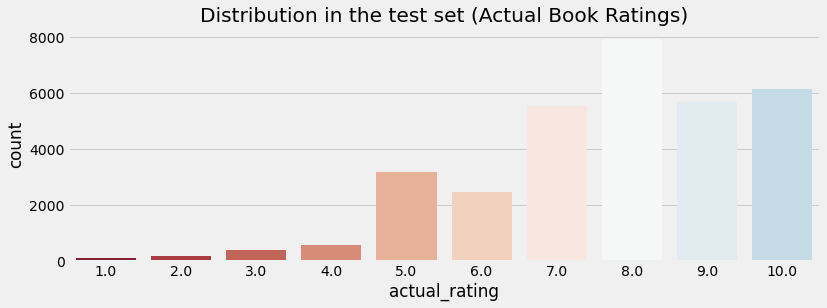

In [80]:
palette = sns.color_palette("RdBu", 15)
fig = plt.figure(figsize=(12, 4))

plot = sns.countplot(x='actual_rating', data=prediction_df, palette=palette)

plot.set_title('Distribution in the test set (Actual Book Ratings)')

plt.show()

Text(0.5, 1.0, 'Distribution in the test set(Predicted Book Rating)')

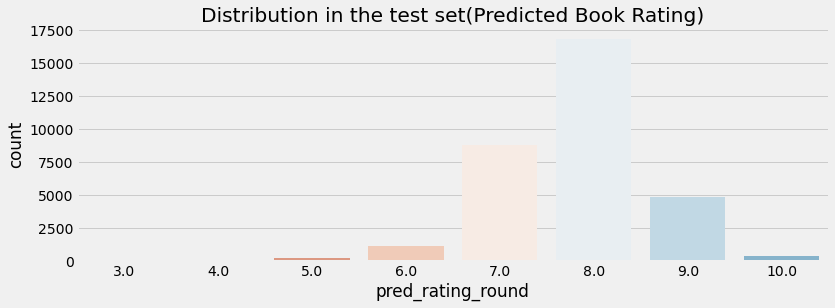

In [81]:
palette = sns.color_palette("RdBu", 10)

fig = plt.figure(figsize=(12, 4))

plot = sns.countplot(x='pred_rating_round', data=prediction_df, palette=palette)

plot.set_title('Distribution in the test set(Predicted Book Rating)')


## Absolute Error

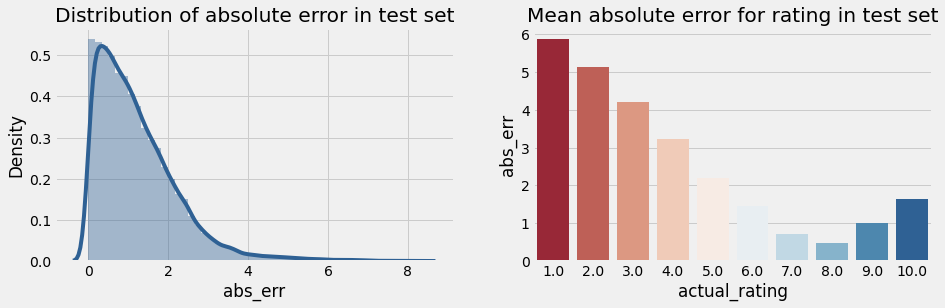

In [82]:
error_df = prediction_df.groupby('actual_rating')['abs_err'].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 4))

sns.distplot(prediction_df['abs_err'], color='#2f6194', ax=ax1)
ax1.set_title('Distribution of absolute error in test set')

sns.barplot(x='actual_rating', y='abs_err', data=error_df, palette=palette, ax=ax2)
ax2.set_title('Mean absolute error for rating in test set')

plt.show()

## Analysis of Rating predicted 

In [83]:
book_copy_df = books_df.copy()
book_copy_df.rename(columns = {'ISBN':'isbn' ,'Book-Title':'book_title'},inplace=True)

In [84]:
df_final = df_rating.merge(book_copy_df[['isbn', 'book_title']], on='isbn', how='left')
df_final = df_final.merge(prediction_df[['isbn', 'user_id', 'pred_rating']], on=['isbn', 'user_id'], how='left')

In [85]:
selected_user_id = 161041

user_df = df_final[df_final['user_id']==selected_user_id]

user_df[(user_df['pred_rating'].isna())&(user_df['book_rating']>=9)].sample(5)

,user_id,isbn,book_rating,Avg_Rating,Total_No_Of_Users_Rated,book_title,pred_rating
96026,161041,0679723161,10,8.360000,50,Lolita (Vintage International),NaN
96018,161041,0486415872,10,9.200000,5,Crime and Punishment (Dover Thrift Editions),NaN
96031,161041,0684801221,10,8.406250,32,OLD MAN AND THE SEA,NaN
96006,161041,0156001314,10,8.523810,21,The Name of the Rose: including Postscript to ...,NaN
96027,161041,0679732241,10,7.066667,15,The Sound and the Fury (Vintage International),NaN


In [86]:
user_df[user_df['pred_rating'].notna()].sort_values('pred_rating', ascending=False).head(5)

,user_id,isbn,book_rating,Avg_Rating,Total_No_Of_Users_Rated,book_title,pred_rating
96019,161041,0553208845,7,8.500000,52,Siddhartha,9.183998
96035,161041,2070360024,10,8.185185,27,"L'Etranger (Collection Folio, 2)",8.931714
96023,161041,0671722859,10,8.473684,19,ROMEO AND JULIET,8.896680
96022,161041,0553213695,10,7.933333,30,The Metamorphosis (Bantam Classics),8.675438
95996,161041,0060907002,8,8.000000,8,No One Writes to the Colonel,8.655946


In [87]:
user_df[user_df['pred_rating'].notna()].sort_values('book_rating', ascending=False).head(5)

,user_id,isbn,book_rating,Avg_Rating,Total_No_Of_Users_Rated,book_title,pred_rating
96010,161041,0156996936,10,8.000000,4,The Year of the Death of Ricardo Reis,8.111653
96022,161041,0553213695,10,7.933333,30,The Metamorphosis (Bantam Classics),8.675438
96023,161041,0671722859,10,8.473684,19,ROMEO AND JULIET,8.896680
96035,161041,2070360024,10,8.185185,27,"L'Etranger (Collection Folio, 2)",8.931714
96036,161041,2070360644,9,6.500000,4,Caligula Le Malentendu (Folio No. 64),7.866706


## Collaborative filtering 

## Item -Item Based 

In [88]:
top_ratings.rename(columns={'user_id':'userID' ,'isbn':'ISBN','book_rating':'bookRating'},inplace=True)

In [89]:
top_ratings.head(15)

,userID,ISBN,bookRating,Avg_Rating,Total_No_Of_Users_Rated
16,276747,0060517794,9,8.000000,30
19,276747,0671537458,9,7.176471,17
20,276747,0679776818,8,7.476190,21
59,276772,0553572369,7,6.625000,8
61,276772,3499230933,10,7.166667,6
83,276788,0345443683,8,7.950000,20
84,276788,043935806X,7,9.033981,206
85,276788,055310666X,10,7.857143,14
97,276798,3548603203,6,8.200000,10
133,276822,0060096195,10,8.132075,53


## Implementing KNN

In [90]:
## Rating Matrix Generation

matrix_rating = top_ratings.pivot(index='userID', columns='ISBN', values='bookRating')
userID = matrix_rating.index
ISBN = matrix_rating.columns
print(matrix_rating.shape)

(18549, 13740)


In [91]:
matrix_rating.head(10)

ISBN,0002005018,0002251760,0002558122,0003300277,000617616X,0006480764,000648302X,0006485200,000649840X,0006511767,...,9500723832,950491036X,9505156642,9505156944,9580464162,958704049X,9681500555,9722016563,9812327975,9871138148
userID,,,,,,,,,,,,,,,,,,,,,
8,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
232,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
n_users = matrix_rating.shape[0] #considering only those users who gave explicit ratings
n_books = matrix_rating.shape[1]
print (n_users, n_books)

18549 13740


In [93]:
matrix_rating.fillna(0, inplace = True)
matrix_rating = matrix_rating.astype(np.int32)

In [94]:
matrix_rating.head(10)

ISBN,0002005018,0002251760,0002558122,0003300277,000617616X,0006480764,000648302X,0006485200,000649840X,0006511767,...,9500723832,950491036X,9505156642,9505156944,9580464162,958704049X,9681500555,9722016563,9812327975,9871138148
userID,,,,,,,,,,,,,,,,,,,,,
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
92,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
114,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
165,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
232,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
242,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
sparse = 1.0-len(ratings_value_df)/float(ratings_value_df.shape[0]*n_books)
print ('The sparsity level of Book Crossing dataset is ' +  str(sparse*100) + ' %')

The sparsity level of Book Crossing dataset is 99.99272197962155 %


In [96]:
merge_books_df = pd.merge(ratings_df, books_df, on = 'ISBN')
columns = ['Book-Author','Year-Of-Publication', 'Publisher']

In [97]:
merge_books_df = merge_books_df.drop(columns, axis = 1)
merge_books_df.rename(columns={'User-ID':'userID','Book-Title':'bookTitle','Book-Rating':'bookRating'},inplace=True)
merge_books_df.head()

,userID,ISBN,bookRating,bookTitle,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,2313,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
2,6543,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
3,8680,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
4,10314,034545104X,9,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...


In [98]:
merge_books_df = merge_books_df.dropna(axis = 0, subset = ['bookTitle'])

In [99]:
count_bookrating = (merge_books_df.
                    groupby(by = ['bookTitle',])['bookRating'].
                    count().
                    reset_index().
                    rename(columns = {'bookRating':'TotalRatingCount'})
                    [['bookTitle','TotalRatingCount']])

In [100]:
count_bookrating.head(5)

,bookTitle,TotalRatingCount
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1


In [101]:
bookdataset_final = merge_books_df.merge(count_bookrating, left_on = 'bookTitle', right_on = 'bookTitle', how = 'inner' )

In [102]:
bookdataset_final.head(10)

,userID,ISBN,bookRating,bookTitle,Image-URL-S,Image-URL-M,Image-URL-L,TotalRatingCount
0,276725,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
1,2313,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
2,6543,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
3,8680,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
4,10314,034545104X,9,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
5,23768,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
6,28266,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
7,28523,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
8,39002,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
9,50403,034545104X,9,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60


In [103]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
print(count_bookrating['TotalRatingCount'].describe())

count   241071.000
mean         4.277
std         16.739
min          1.000
25%          1.000
50%          1.000
75%          3.000
max       2502.000
Name: TotalRatingCount, dtype: float64


In [104]:
print(count_bookrating['TotalRatingCount'].quantile(np.arange(.9,1,.01)))

0.900    7.000
0.910    8.000
0.920    9.000
0.930   10.000
0.940   11.000
0.950   13.000
0.960   16.000
0.970   20.000
0.980   29.000
0.990   50.000
Name: TotalRatingCount, dtype: float64


In [105]:
thres_popular = 50
popular_books = bookdataset_final.query('TotalRatingCount >= @thres_popular')

In [106]:
popular_books.count()

userID              288740
ISBN                288740
bookRating          288740
bookTitle           288740
Image-URL-S         288740
Image-URL-M         288740
Image-URL-L         288740
TotalRatingCount    288740
dtype: int64

In [107]:
popular_books.head(5)

,userID,ISBN,bookRating,bookTitle,Image-URL-S,Image-URL-M,Image-URL-L,TotalRatingCount
0,276725,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
1,2313,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
2,6543,034545104X,0,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
3,8680,034545104X,5,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60
4,10314,034545104X,9,Flesh Tones: A Novel,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,60


In [108]:
if not popular_books[popular_books.duplicated(['userID', 'bookTitle'])].empty:
    ini_rec = popular_books.shape[0]

    print('Initial dataframe shape {0}'.format(popular_books.shape))
    popular_books = popular_books.drop_duplicates(['userID', 'bookTitle'])
    cur_rec = popular_books.shape[0]
    print('New dataframe shape {0}'.format(popular_books.shape))
    print('Removed {0} rows'.format(ini_rec - cur_rec))

Initial dataframe shape (288740, 8)
New dataframe shape (285518, 8)
Removed 3222 rows


In [109]:
popular_books_final = popular_books.pivot(index = 'bookTitle',columns = 'userID', values = 'bookRating').fillna(0)

popular_books_final_matrix = csr_matrix(popular_books_final.values)

## Training KNN

In [110]:
knn_model = NearestNeighbors(metric = 'cosine', algorithm = 'brute')

In [111]:
knn_model.fit(popular_books_final_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [112]:
query_index = np.random.choice(popular_books_final_matrix.shape[0])

distances, indices = knn_model.kneighbors(popular_books_final.iloc[query_index, :].values.reshape((1, -1)), n_neighbors = 6)

for i in range(0, len(distances.flatten())):
    if i == 0:
        print('Recommendations for {0}:\n'.format(popular_books_final.index[query_index]))
    else:
        print('{0}: {1}, with distance of {2}:'.format(i, popular_books_final.index[indices.flatten()[i]], distances.flatten()[i]))

Recommendations for It Was on Fire When I Lay Down on It:

1: All I Really Need to Know, with distance of 0.8230211488809551:
2: All Creatures Great and Small, with distance of 0.8716442129813443:
3: Uh-Oh: Some Observations from Both Sides of the Refrigerator Door, with distance of 0.893568206272682:
4: The Bonesetter's Daughter, with distance of 0.9125790663612985:
5: Hawaii, with distance of 0.9156473432697738:


In [113]:
popular_books2 = popular_books.pivot(index = 'userID', columns = 'bookTitle', values = 'bookRating').fillna(0)

In [114]:
popular_books2

bookTitle,10 Lb. Penalty,16 Lighthouse Road,1984,1st to Die: A Novel,2010: Odyssey Two,204 Rosewood Lane,2061: Odyssey Three,24 Hours,2nd Chance,3rd Degree,...,YOU BELONG TO ME,Year of Wonders,You Belong To Me,You Shall Know Our Velocity,Young Wives,Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,Zoya,"\O\"" Is for Outlaw""","\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""",stardust
userID,,,,,,,,,,,,,,,,,,,,,
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
14,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
16,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
17,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278843,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
278844,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
278846,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [115]:
popular_books2.shape

(47994, 2444)

In [116]:
## Transpose

popular_books2_transpose= popular_books2.values.T
popular_books2_transpose.shape

(2444, 47994)

In [117]:
SVD = TruncatedSVD(n_components=12, random_state=17)

matrix_final = SVD.fit_transform(popular_books2_transpose)

matrix_final.shape

(2444, 12)

In [118]:
corr_books = np.corrcoef(matrix_final)

corr_books.shape

(2444, 2444)

## Book Based Recommendation

In [119]:
book_title_df = popular_books2.columns
book_title_lst = list(book_title_df)
book_index = book_title_lst.index("Year of Wonders")

In [120]:
corr_book_index  = corr_books[book_index]

In [121]:
list(book_title_df[(corr_book_index<1.0) & (corr_book_index>0.9)])

["A Thousand Acres (Ballantine Reader's Circle)",
 'Affinity',
 'Alias Grace',
 'Animal Dreams',
 'Atonement : A Novel',
 'Behind the Scenes at the Museum : A Novel',
 'Black and Blue : A Novel',
 'Charming Billy',
 'Cold Mountain : A Novel',
 "Corelli's Mandolin : A Novel",
 'Daisy Fay and the Miracle Man',
 'Empire Falls',
 'Gap Creek: A Novel',
 'Girl with a Pearl Earring',
 "I Don't Know How She Does It: The Life of Kate Reddy, Working Mother",
 'Into Thin Air : A Personal Account of the Mt. Everest Disaster',
 'Keeping Faith : A Novel',
 'Little Altars Everywhere: A Novel',
 'Lying Awake',
 'Moo',
 'My Dream of You',
 'Nickel and Dimed: On (Not) Getting By in America',
 'Plainsong (Vintage Contemporaries)',
 'Prodigal Summer: A Novel',
 'Resistance : A Novel',
 'STONES FROM THE RIVER',
 'The Bean Trees',
 'The Blind Assassin',
 'The Cider House Rules',
 "The Dress Lodger (Ballantine Reader's Circle)",
 "The Liar's Club: A Memoir",
 'The Man Who Ate the 747',
 'The River King',
 'T

## Collaborative Filtering

## User Based 

In [122]:
ratings_value_df.rename(columns={'user_id':'User-ID','isbn':'ISBN','book_rating':'Book-Rating'},inplace=True)

In [123]:
ratings_value_df.head()

,User-ID,ISBN,Book-Rating,Avg_Rating,Total_No_Of_Users_Rated
1,276726,0155061224,5,5.000,1
3,276729,052165615X,3,3.000,1
4,276729,0521795028,6,6.000,1
8,276744,038550120X,7,7.580,81
16,276747,0060517794,9,8.000,30


In [124]:
interactions_df = ratings_value_df.groupby(['ISBN', 'User-ID']).size().groupby('User-ID').size()
print('# of users: %d' % len(interactions_df))

# of users: 68091


In [125]:
interactions_df_user = interactions_df[interactions_df >= 100].reset_index()[['User-ID']]
print('# of users with at least 5 interactions: %d' % len(interactions_df_user))

# of users with at least 5 interactions: 449


In [126]:
print('# of interactions: %d' % len(ratings_value_df))
final_user_df = ratings_value_df.merge(interactions_df_user, 
               how = 'right',
               left_on = 'User-ID',
               right_on = 'User-ID')

# of interactions: 383842


In [127]:
print('# of interactions from users with at least 5 interactions: %d' % len(final_user_df))

# of interactions from users with at least 5 interactions: 103271


In [128]:
final_user_df.head(5)

,User-ID,ISBN,Book-Rating,Avg_Rating,Total_No_Of_Users_Rated
0,2033,0030020786,7,7.000,1
1,2033,0060248025,10,8.767,30
2,2033,0060256664,10,8.333,6
3,2033,0060256737,10,9.045,22
4,2033,0060950536,10,9.400,5


In [129]:
def preference_user(x):
    return math.log(1+x, 2)

In [130]:
final_dataset = final_user_df.groupby(['ISBN', 'User-ID'])['Book-Rating'].sum().apply(preference_user).reset_index()
print('# of unique user/item interactions: %d' % len(final_dataset))
final_dataset.head()

# of unique user/item interactions: 103271


,ISBN,User-ID,Book-Rating
0,0000913154,171118,3.170
1,0001046438,23902,3.322
2,000104687X,23902,2.807
3,0001047213,23902,3.322
4,0001047973,23902,3.322


In [131]:
from sklearn.model_selection import train_test_split

x_train_user, x_test_user = train_test_split(final_dataset,stratify=final_dataset['User-ID'],test_size=0.20,random_state=42)

print('# interactions on Train set: %d' % len(x_train_user))
print('# interactions on Test set: %d' % len(x_test_user))

# interactions on Train set: 82616
# interactions on Test set: 20655


In [132]:
matrix_user = x_train_user.pivot(index='User-ID', columns='ISBN', values='Book-Rating').fillna(0)

matrix_user.head()

ISBN,0000913154,000104687X,0001047213,0001047973,000104799X,0001048082,0001053736,0001055607,0001056107,0001845039,...,B00007FYKW,B00008RWPV,B00009NDAN,B0000DYXID,B0000T6KHI,B0000VZEJQ,B0000X8HIE,B00013AX9E,B0001I1KOG,B000234N3A
User-ID,,,,,,,,,,,,,,,,,,,,,
2033,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2110,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2276,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4017,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4385,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [133]:
matrix_user_lst = matrix_user.values

matrix_user_lst[:10]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [134]:
id_user = list(matrix_user.index)

id_user[:10]

[2033, 2110, 2276, 4017, 4385, 5582, 6242, 6251, 6543, 6575]

In [135]:
factors = 15

## Matrix factorization on the user matrix

lst_u, lst_s, lst_V = svds(matrix_user_lst, k = factors)

lst_s = np.diag(lst_s)

In [136]:
lst_u.shape,lst_s.shape,lst_V.shape

((449, 15), (15, 15), (15, 55743))

In [137]:
predicted_ratings_user = np.dot(np.dot(lst_u, lst_s), lst_V) 
predicted_ratings_user

array([[ 1.48048195e-02,  2.31728082e-03,  2.74202603e-03, ...,
         2.27788796e-04,  5.49322969e-04,  1.26270997e-02],
       [-7.38279388e-04, -8.94254584e-04, -1.05816668e-03, ...,
         8.58241199e-05,  1.78651132e-04,  4.24690377e-03],
       [-2.00559626e-03, -1.73047641e-03, -2.04766350e-03, ...,
         1.78220412e-04,  4.04160623e-04,  7.29766631e-03],
       ...,
       [ 4.20550556e-03,  1.96625381e-03,  2.32665764e-03, ...,
         2.49809614e-04,  4.73258210e-04,  8.35154052e-03],
       [ 1.13675090e-02, -2.21445596e-03, -2.62035392e-03, ...,
         3.41186005e-04,  6.59446393e-04,  1.16707765e-02],
       [-1.44606285e-03,  5.14009860e-03,  6.08225124e-03, ...,
         8.58660344e-05,  1.46974496e-04,  2.89210573e-03]])

In [138]:
#Converting the reconstructed matrix back to a Pandas dataframe
prediction_data= pd.DataFrame(predicted_ratings_user, columns = matrix_user.columns, index=id_user).transpose()
prediction_data.head()

,2033,2110,2276,4017,4385,5582,6242,6251,6543,6575,...,269566,270713,271448,271705,273113,274061,274301,275970,277427,278418
ISBN,,,,,,,,,,,,,,,,,,,,,
0000913154,0.015,-0.001,-0.002,0.001,-0.002,-0.003,-0.003,0.007,0.001,0.013,...,0.001,0.003,-0.002,0.008,-0.012,0.001,0.008,0.004,0.011,-0.001
000104687X,0.002,-0.001,-0.002,0.017,-0.001,0.009,0.014,0.007,-0.003,0.016,...,-0.002,0.013,-0.001,0.014,-0.005,-0.006,0.008,0.002,-0.002,0.005
0001047213,0.003,-0.001,-0.002,0.020,-0.001,0.010,0.016,0.009,-0.004,0.019,...,-0.003,0.016,-0.001,0.016,-0.005,-0.007,0.009,0.002,-0.003,0.006
0001047973,0.003,-0.001,-0.002,0.020,-0.001,0.010,0.016,0.009,-0.004,0.019,...,-0.003,0.016,-0.001,0.016,-0.005,-0.007,0.009,0.002,-0.003,0.006
000104799X,0.001,0.000,0.001,0.002,0.000,0.001,0.001,0.002,0.002,0.004,...,0.001,0.002,0.003,0.001,0.002,0.002,0.002,0.001,0.001,0.000


In [139]:
books_df.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [140]:
class Recommender_CF:
    
    model_name = 'Collaborative Filtering'
    
    def __init__(self, func_df):
        self.func_df = func_df
        
    def get_model_name(self):
        return self.model_name
        
    def recommend_items(self, id_val, items=[], n=10):
        
        # Get and sort the user's predictions
        prediction_sorted = self.func_df[id_val].sort_values(ascending=False).reset_index().rename(columns={id_val: 'recStrength'})

        # Recommend the highest predicted rating content that the user hasn't seen yet.
        recom_df = prediction_sorted[~prediction_sorted['ISBN'].isin(items)].sort_values('recStrength', ascending = False).head(n)
        recom_df=recom_df.merge(books_df,on='ISBN',how='inner')
        recom_df=recom_df[['ISBN','Book-Title','recStrength']]


        return recom_df



recommender_cf_model = Recommender_CF(prediction_data)

In [141]:
#Indexing by Id to speed up the searches during evaluation

final_index = final_dataset.set_index('User-ID')
final_train_index = x_train_user.set_index('User-ID')
final_test_index = x_test_user.set_index('User-ID')

In [142]:
def item_list(UserID, set_df):
    item_collected = set_df.loc[UserID]['ISBN']
    return set(item_collected if type(item_collected) == pd.Series else [item_collected])

In [143]:
class ModelRecommender:

    # Function for getting the set of items which a user has not interacted with
    
    def item_sample_collection(self, id, s_size, seed=42):
        item_collected = item_list(id, final_index)
        entire_set = set(ratings_value_df['ISBN'])
        collect_item = entire_set - item_collected

        random.seed(seed)
        
        collect_item_samp = random.sample(collect_item, s_size)
        return set(collect_item_samp)

    # Function to verify whether a particular item_id was present in the set of top N recommended items
    
    def _verify_hit_top_n(self, i_id, rec_item, n):        
            try:
                index = next(i for i, c in enumerate(rec_item) if c == i_id)
            except:
                index = -1
            hit = int(index in range(0, n))
            return hit, index
    
    # Function to evaluate the performance of model for each user
    def evaluate_models(self, model, p_id):
        
        # Getting the items in test set
        value_test = final_test_index.loc[p_id]
        
        if type(value_test['ISBN']) == pd.Series:
            p_value = set(value_test['ISBN'])
        else:
            p_value = set([int(value_test['ISBN'])])
            
        item_count = len(p_value) 

        # Getting a ranked recommendation list from the model for a given user
        records_df = model.recommend_items(p_id, items=item_list(p_id, final_train_index),n=10000000000)
        print('Recommendation for User-ID = ',p_id)
        print(records_df.head(10))

        # Function to evaluate the performance of model at overall level
    def recommend_book(self, model ,id):
        
        p_metrics = self.evaluate_models(model,id )  
        return

model_recommender = ModelRecommender()    

In [144]:
print(list(final_index.index.values))

[171118, 23902, 23902, 23902, 23902, 166596, 23902, 109901, 189835, 189835, 85526, 93047, 95359, 56399, 229329, 11676, 69078, 63714, 101606, 11676, 36907, 85526, 26583, 120565, 101606, 11676, 193560, 262998, 23902, 63714, 11676, 159506, 189835, 11676, 180651, 63714, 193560, 274301, 120565, 30511, 189334, 189334, 275970, 166596, 23902, 6242, 101606, 101851, 11676, 95010, 11676, 37712, 123883, 94853, 23902, 23902, 11676, 189334, 11676, 11676, 149908, 30511, 94853, 225087, 172742, 120565, 16634, 88733, 218552, 264321, 189334, 56271, 11676, 63714, 6543, 30511, 134434, 76626, 240543, 26583, 248718, 76626, 56399, 270713, 168245, 168245, 98758, 23902, 63714, 107784, 37644, 37644, 168245, 164096, 35859, 177458, 136010, 197659, 23902, 11676, 11676, 23902, 78973, 200226, 30810, 11676, 242006, 225087, 11676, 274301, 11676, 30511, 193560, 189835, 39281, 120565, 11676, 183958, 11676, 148199, 23902, 109955, 76626, 193560, 148258, 11676, 63714, 85526, 109955, 23902, 225232, 148258, 189334, 105517, 62

## Enter User Id

In [145]:
user=int(input("Enter User ID from above list for book recommendation  "))
model_recommender.recommend_book(recommender_cf_model,user)

Enter User ID from above list for book recommendation  11676
Recommendation for User-ID =  11676
         ISBN                                         Book-Title  recStrength
0  0385504209                                  The Da Vinci Code        0.102
1  0452282152                          Girl with a Pearl Earring        0.078
2  0312980140                  Seven Up (A Stephanie Plum Novel)        0.077
3  0553250531                               The Valley of Horses        0.064
4  0440214041                                  The Pelican Brief        0.062
5  0440212561                                          Outlander        0.060
6  0440220602                                        The Chamber        0.060
7  0743418174                                        Good in Bed        0.060
8  0385492081  Into Thin Air : A Personal Account of the Mt. ...        0.059
9  0446606812                                Message in a Bottle        0.058


## Evalution 

In [146]:
#Top-N accuracy metrics consts
random_val = 100

class ModelEvaluator:

    # Function for getting the set of items which a user has not interacted with
    def sample_collect(self, u_id, s_size, seed=42):
        collect_item = item_list(u_id, final_index)
        item = set(ratings_value_df['ISBN'])
        item_no = item - collect_item

        random.seed(seed)
        no_item_sample = random.sample(item_no, s_size)
        return set(no_item_sample)

    # Function to verify whether a particular item_id was present in the set of top N recommended items
    def _verify_hit_top_n(self, i_id, rec_item, n):        
            try:
                index = next(i for i, c in enumerate(rec_item) if c == i_id)
            except:
                index = -1
            hit = int(index in range(0, n))
            return hit, index
    
    # Function to evaluate the performance of model for each user
    def evaluate_models(self, model, p_id):
        
        # Getting the items in test set
        value_test = final_test_index.loc[p_id]
        
        if type(value_test['ISBN']) == pd.Series:
            p_collect = set(value_test['ISBN'])
        else:
            p_collect = set([int(value_test['ISBN'])])
            
        item_count = len(p_collect) 

        # Getting a ranked recommendation list from the model for a given user
        person_recs_df = model.recommend_items(p_id, items=item_list(p_id, final_train_index),n=10000000000)
        
        hit_5 = 0
        hit_10 = 0
        
        # For each item the user has interacted in test set
        for item_id in p_collect:
            
            # Getting a random sample of 100 items the user has not interacted with
            non_item_collected_sample = self.sample_collect(p_id, s_size=random_val, seed=item_id)   

            # Combining the current interacted item with the 100 random items
            items_to_filter_recs = non_item_collected_sample.union(set([item_id]))

            # Filtering only recommendations that are either the interacted item or from a random sample of 100 non-interacted items
            valid_recs_df = person_recs_df[person_recs_df['ISBN'].isin(items_to_filter_recs)]                    
            valid_recs = valid_recs_df['ISBN'].values
            
            # Verifying if the current interacted item is among the Top-N recommended items
            hit_at_5, index_at_5 = self._verify_hit_top_n(item_id, valid_recs, 5)
            hit_5 += hit_at_5
            hit_at_10, index_at_10 = self._verify_hit_top_n(item_id, valid_recs, 10)
            hit_10 += hit_at_10

        # Recall is the rate of the interacted items that are ranked among the Top-N recommended items
        recall_5 = hit_5 / float(item_count)
        recall_10 = hit_10 / float(item_count)

        pmetrics = {'hits@5_count':hit_5, 
                          'hits@10_count':hit_10, 
                          'interacted_count': item_count,
                          'recall@5': recall_5,
                          'recall@10': recall_10}
        return pmetrics

    
    # Function to evaluate the performance of model at overall level
    def evaluate_model(self, model):
        
        pe_metrics = []
        
        for idx, p_id in enumerate(list(final_test_index.index.unique().values)):    
            pmetrics = self.evaluate_models(model, p_id)  
            pmetrics['User-ID'] = p_id
            pe_metrics.append(pmetrics)
            
        print('%d users processed' % idx)

        res_df = pd.DataFrame(pe_metrics).sort_values('interacted_count', ascending=False)
        
        global_5 = res_df['hits@5_count'].sum() / float(res_df['interacted_count'].sum())
        global_10 = res_df['hits@10_count'].sum() / float(res_df['interacted_count'].sum())
        
        g_metrics = {'modelName': model.get_model_name(),
                          'recall@5': global_5,
                          'recall@10': global_10}    
        return g_metrics, res_df
    
model_evaluator = ModelEvaluator()    

In [147]:
print('Evaluating Collaborative Filtering (SVD Matrix Factorization) model...')
cf_global_metrics, cf_detailed_results_df = model_evaluator.evaluate_model(recommender_cf_model)

print('\nGlobal metrics:\n%s' % cf_global_metrics)
cf_detailed_results_df.head(10)

Evaluating Collaborative Filtering (SVD Matrix Factorization) model...
448 users processed

Global metrics:
{'modelName': 'Collaborative Filtering', 'recall@5': 0.23606874848704915, 'recall@10': 0.304962478818688}


,hits@5_count,hits@10_count,interacted_count,recall@5,recall@10,User-ID
10,259,336,1389,0.186,0.242,11676
31,190,245,1138,0.167,0.215,98391
45,20,30,380,0.053,0.079,189835
30,84,104,369,0.228,0.282,153662
70,30,35,236,0.127,0.148,23902
7,27,47,204,0.132,0.230,235105
47,24,27,203,0.118,0.133,76499
50,25,37,193,0.130,0.192,171118
42,61,70,192,0.318,0.365,16795
43,21,31,188,0.112,0.165,248718
